 Photography Location Recommender System  ด้วย Graph<br>แนวคิดคือ ผู้ใช้ชอบหรือสนใจสถานที่ถ่ายรูปแบบไหน → หา User คนอื่นที่มีความชอบคล้ายกัน → ดูว่าสถานที่อื่นที่ User เหล่านั้นชอบ → แนะนำสถานที่นั้นกลับมา

ตัวอย่างสถานการณ์ มีผู้ใช้ 10 คน <br>

```
Pim
Beam
Mew
Film
Nina
Earth
Praew
Win
View
Mark
```

และมีสถานที่ถ่ายรูป

```
ICONSIAM
Talad Noi
Asiatique The Riverfront
Benjakitti Park
Chatuchak Weekend Market
The commons Thonglor
Wat Arun
Yaowarat
Bangkok Art and Culture Centre
Ancient City
```

สมมติข้อมูลความชอบคือ

```
Pim   → ICONSIAM
Pim   → Talad Noi

Beam     → ICONSIAM
Beam     → Talad Noi
Beam     → Yaowarat

Mew → Talad Noi
Mew → Bangkok Art and Culture Centre

Film   → Yaowarat
Film   → Chatuchak Weekend Market

Nina → Benjakitti Park
Nina → The Commons Thonglor

Earth → Benjakitti Park
Earth → The Commons Thonglor
Earth → Asiatique The Riverfront

Praew → Wat Arun
Praew → ICONSIAM

Win → Wat Arun
Win → Yaowarat

View → Chatuchak Weekend Market
View → Ancient City

Mark → Ancient City
Mark → Asiatique The Riverfront
```



```
เราจะสังเกตได้ว่า
Pim และ Beam ชอบ ICONSIAM และ Talad Noi เหมือนกัน
แต่ Beam ยังชอบ
Yaowarat
ดังนั้นระบบสามารถคิดง่าย ๆ ว่า
ถ้า Pim กับ Beam มีความชอบสถานที่ถ่ายรูปคล้ายกัน
และ Beam ชอบ Yaowarat แต่ Pim ยังไม่ได้เลือก Yaowarat
ระบบอาจแนะนำ Yaowarat ให้ Pim
นี่คือ Recommender System แบบ Graph อย่างง่าย
สำหรับแนะนำสถานที่ถ่ายรูป

```



การออกแบบ Graph

```
เราแบ่ง Node เป็น 2 ประเภท

User
สถานที่ถ่ายรูป

Relationship คือ

LIKES

ดังนั้น

(User)-[:LIKES]->(สถานที่ถ่ายรูป)

เช่น

(Pim)-[:LIKES]->(ICONSIAM)
```


**สร้างด้วย Python บน Google Colab**

In [ ]:
!pip -q install networkx

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

In [ ]:
G = nx.Graph()

In [ ]:
#add user
users = [
    "Pim", "Beam", "Mew", "Film", "Nina",
    "Earth", "Praew", "Win", "View", "Mark"
]

for user in users:
    G.add_node(
        user,
        node_type="user"
    )

In [ ]:
#add photography locations
locations = [
    "ICONSIAM", "Talad Noi", "Asiatique The Riverfront",
    "Benjakitti Park", "Chatuchak Weekend Market", "The Commons Thonglor",
    "Wat Arun", "Yaowarat", "Bangkok Art and Culture Centre", "Ancient City"
]

for location in locations:
    G.add_node(
        location,
        node_type="location"
    )

In [ ]:
#add relationship
likes = [
    ("Pim", "ICONSIAM"),
    ("Pim", "Talad Noi"),

    ("Beam", "ICONSIAM"),
    ("Beam", "Talad Noi"),
    ("Beam", "Yaowarat"),

    ("Mew", "Talad Noi"),
    ("Mew", "Bangkok Art and Culture Centre"),

    ("Film", "Yaowarat"),
    ("Film", "Chatuchak Weekend Market"),

    ("Nina", "Benjakitti Park"),
    ("Nina", "The Commons Thonglor"),

    ("Earth", "Benjakitti Park"),
    ("Earth", "The Commons Thonglor"),
    ("Earth", "Asiatique The Riverfront"),

    ("Praew", "Wat Arun"),
    ("Praew", "ICONSIAM"),

    ("Win", "Wat Arun"),
    ("Win", "Yaowarat"),

    ("View", "Chatuchak Weekend Market"),
    ("View", "Ancient City"),

    ("Mark", "Ancient City"),
    ("Mark", "Asiatique The Riverfront")
]

เพิ่มเข้า Graph

In [ ]:
G.add_edges_from(likes)

วาด Graph

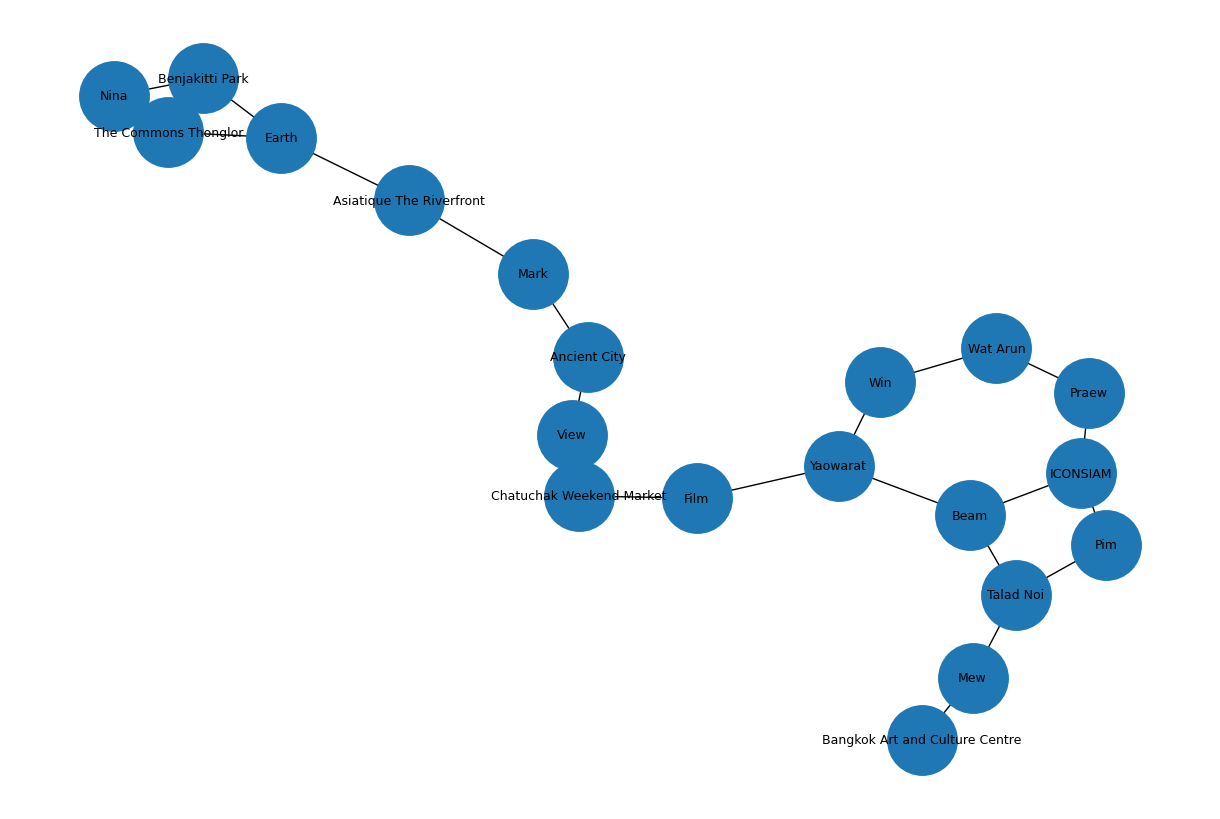

In [ ]:
plt.figure(figsize=(12, 8))

pos = nx.spring_layout(
    G,
    seed=42
)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=2500,
    font_size=9
)

plt.show()

คำถามแรก <br>
1.ถามว่า Pim ชอบสถานที่ถ่ายรูปที่ไหนบ้าง?

In [ ]:
pim_locations = list(
    G.neighbors("Pim")
)

print(pim_locations)

['ICONSIAM', 'Talad Noi']


ตรงนี้อธิบายได้ว่า Neighbor ของ Pim คือ Node ที่เชื่อมกับ Pim

คำถามที่ 2. หา User ที่ชอบสถานที่ถ่ายรูปเหมือน Pim <br>
Pim ชอบ ICONSIAM และ Talad Noi<br>
เราสามารถหาได้ว่าใครชอบสถานที่ถ่ายรูปเหล่านี้เหมือนกัน

In [ ]:
for location in G.neighbors("Pim"):

    print("Location:", location)

    for user in G.neighbors(location):

        if user != "Pim":
            print("  Similar user:", user)

Location: ICONSIAM
  Similar user: Beam
  Similar user: Praew
Location: Talad Noi
  Similar user: Beam
  Similar user: Mew


**สร้าง Recommendation แบบง่าย**

```
แนวคิดคือ

Pim
 ↓
สถานที่ถ่ายรูปที่ Pim ชอบ
 ↓
User ที่ชอบสถานที่ถ่ายรูปเดียวกัน
 ↓
สถานที่ถ่ายรูปที่ User เหล่านั้นชอบ
 ↓
แนะนำให้ Pim
```



In [ ]:
from collections import Counter


target_user = "Pim"

recommendations = Counter()


# สถานที่ถ่ายรูปที่ Pim ชอบแล้ว
liked_locations = set(
    G.neighbors(target_user)
)


# ดูสถานที่ถ่ายรูปแต่ละแห่งที่ Pim ชอบ
for location in liked_locations:

    # หา User ที่ชอบสถานที่ถ่ายรูปที่เดียวกัน
    for similar_user in G.neighbors(location):

        if similar_user == target_user:
            continue

        # ดูว่า User คนนั้นชอบสถานที่ถ่ายรูปอะไรอีก
        for other_location in G.neighbors(similar_user):

            # Pim ยังไม่เคยเลือกสถานที่นี้
            if other_location not in liked_locations:

                recommendations[other_location] += 1


print(recommendations)

Counter({'Yaowarat': 2, 'Bangkok Art and Culture Centre': 1, 'Wat Arun': 1})


In [ ]:
# นำไปสร้างเป็นฟังก์ชัน

In [ ]:
from collections import Counter


# ==================================
# สร้างฟังก์ชันแนะนำสถานที่ถ่ายรูป
# ==================================

def recommend_locations(G, target_user):

    # ใช้เก็บสถานที่ที่ระบบจะแนะนำและคะแนนของแต่ละสถานที่
    recommendations = Counter()

    # หาสถานที่ถ่ายรูปที่ User เป้าหมายชอบ
    liked_locations = set(
        G.neighbors(target_user)
    )

    # วนดูสถานที่แต่ละแห่งที่ User เป้าหมายชอบ
    for location in liked_locations:

        # หา User คนอื่นที่ชอบสถานที่เดียวกัน
        for similar_user in G.neighbors(location):

            # ไม่ต้องนำ User เป้าหมายมาเปรียบเทียบกับตัวเอง
            if similar_user == target_user:
                continue

            # หาสถานที่อื่นที่ User ที่มีความชอบคล้ายกันชอบ
            for other_location in G.neighbors(similar_user):

                # ถ้าเป็นสถานที่ที่ User เป้าหมายยังไม่ได้ชอบ
                # จะเพิ่มคะแนนให้สถานที่นั้น
                if other_location not in liked_locations:

                    recommendations[other_location] += 1

    # เรียงสถานที่ตามคะแนนจากมากไปน้อย
    return recommendations.most_common()

In [ ]:
#เรียกใช้งาน
result = recommend_locations( G, "Pim")
print(result)

[('Yaowarat', 2), ('Bangkok Art and Culture Centre', 1), ('Wat Arun', 1)]


In [ ]:
#เรียกใช้งาน
result = recommend_locations( G, "Beam")
print(result)

[('Wat Arun', 2), ('Chatuchak Weekend Market', 1), ('Bangkok Art and Culture Centre', 1)]


In [ ]:
#เรียกใช้งาน
result = recommend_locations( G, "Mew")
print(result)

[('ICONSIAM', 2), ('Yaowarat', 1)]


In [ ]:
Pim_locations = list(
    G.neighbors("Pim")
)

print(pim_locations)

['ICONSIAM', 'Talad Noi']


โค้ดระบบแนะนำสถานที่ถ่ายรูปด้วย Graph

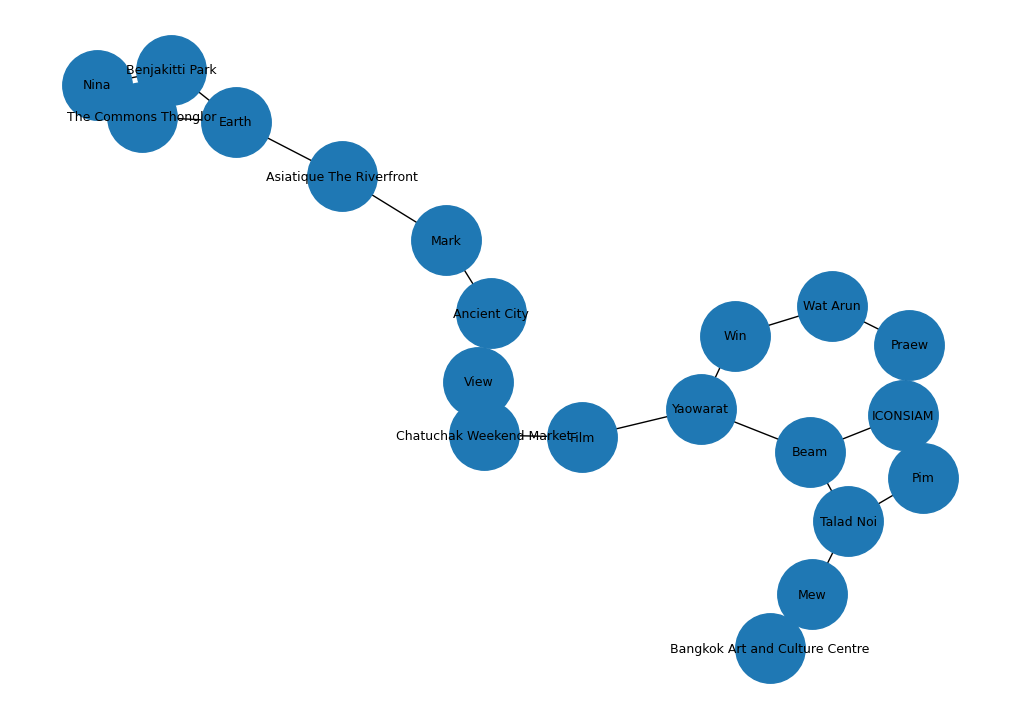

Recommendations for Pim
Yaowarat Score = 2
Bangkok Art and Culture Centre Score = 1
Wat Arun Score = 1


In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

from collections import Counter


# ==================================
# 1. Create Graph
# ==================================

G = nx.Graph()


# ==================================
# 2. Add Users
# ==================================

users = [
    "Pim",
    "Beam",
    "Mew",
    "Film",
    "Nina",
    "Earth",
    "Praew",
    "Win",
    "View",
    "Mark"
]

for user in users:

    G.add_node(
        user,
        node_type="user"
    )


# ==================================
# 3. Add Photography Locations
# ==================================

locations = [
    "ICONSIAM",
    "Talad Noi",
    "Asiatique The Riverfront",
    "Benjakitti Park",
    "Chatuchak Weekend Market",
    "The Commons Thonglor",
    "Wat Arun",
    "Yaowarat",
    "Bangkok Art and Culture Centre",
    "Ancient City"
]

for location in locations:

    G.add_node(
        location,
        node_type="location"
    )


# ==================================
# 4. User-Location Relationships
# ==================================

likes = [

    ("Pim", "ICONSIAM"),
    ("Pim", "Talad Noi"),

    ("Beam", "ICONSIAM"),
    ("Beam", "Talad Noi"),
    ("Beam", "Yaowarat"),

    ("Mew", "Talad Noi"),
    ("Mew", "Bangkok Art and Culture Centre"),

    ("Film", "Yaowarat"),
    ("Film", "Chatuchak Weekend Market"),

    ("Nina", "Benjakitti Park"),
    ("Nina", "The Commons Thonglor"),

    ("Earth", "Benjakitti Park"),
    ("Earth", "The Commons Thonglor"),
    ("Earth", "Asiatique The Riverfront"),

    ("Praew", "Wat Arun"),
    ("Praew", "ICONSIAM"),

    ("Win", "Wat Arun"),
    ("Win", "Yaowarat"),

    ("View", "Chatuchak Weekend Market"),
    ("View", "Ancient City"),

    ("Mark", "Ancient City"),
    ("Mark", "Asiatique The Riverfront")
]


G.add_edges_from(likes)


# ==================================
# 5. Draw Graph
# ==================================

plt.figure(
    figsize=(10, 7)
)


pos = nx.spring_layout(
    G,
    seed=42
)


nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=2500,
    font_size=9
)


plt.show()


# ==================================
# 6. Recommendation Function
# ==================================

# สร้างฟังก์ชันสำหรับแนะนำสถานที่ถ่ายรูป
def recommend_locations(
    G,
    target_user
):

    # สร้างตัวแปรสำหรับเก็บชื่อสถานที่และคะแนนการแนะนำ
    recommendations = Counter()

    # หาสถานที่ถ่ายรูปที่ User เป้าหมายชอบ
    liked_locations = set(
        G.neighbors(
            target_user
        )
    )

    # วนดูสถานที่แต่ละแห่งที่ User เป้าหมายชอบ
    for location in liked_locations:

        # หา User คนอื่นที่ชอบสถานที่เดียวกัน
        for similar_user in G.neighbors(location):

            # ข้าม User เป้าหมาย เพื่อไม่ให้ระบบนำตัวเองมาคำนวณ
            if similar_user == target_user:
                continue

            # หาสถานที่อื่นที่ User ที่มีความชอบคล้ายกันชอบ
            for other_location in G.neighbors(
                similar_user
            ):

                # ตรวจสอบว่าสถานที่นั้นยังไม่อยู่ในรายการที่ User เป้าหมายชอบ
                if other_location not in liked_locations:

                    # เพิ่มคะแนนให้สถานที่ที่พบ
                    recommendations[
                        other_location
                    ] += 1

    # คืนค่ารายการสถานที่ที่แนะนำ โดยเรียงจากคะแนนมากไปน้อย
    return recommendations.most_common()


# ==================================
# 7. Recommend for Pim
# ==================================

# กำหนด User เป้าหมายที่ต้องการให้ระบบแนะนำสถานที่
target_user = "Pim"


# เรียกใช้ฟังก์ชันแนะนำสถานที่
# โดยส่ง Graph และ User เป้าหมายเข้าไป
result = recommend_locations(
    G,
    target_user
)


# แสดงข้อความว่าเป็นผลการแนะนำสำหรับ User คนใด
print(
    "Recommendations for",
    target_user
)


# วนแสดงชื่อสถานที่และคะแนนที่ได้รับ
for location, score in result:

    print(
        location,
        "Score =",
        score
    )

Recommender System แบบ Graph ไม่ได้มองเพียงว่า “สถานที่ถ่ายรูปไหนดี” แต่ดูว่า “ผู้ใช้คนนี้เชื่อมโยงกับผู้ใช้คนอื่นและสถานที่ถ่ายรูปอื่นอย่างไร” จากความสัมพันธ์ของผู้ใช้ที่มีความชอบคล้ายกัน ระบบจึงสามารถนำสถานที่ถ่ายรูปที่ผู้ใช้คนอื่นชื่นชอบมาแนะนำให้กับผู้ใช้ได้